# Delivery Time Prediction - Phase 5: Feature Engineering

## Executive Overview
Welcome to **Phase 5: Feature Engineering** of the Delivery Time Prediction machine learning project.

Following the statistical profiling in **Phase 2 (Dataset Understanding)**, visual discoveries in **Phase 3 (EDA)**, and baseline transformations in **Phase 4 (Data Preprocessing)**, this phase focuses on **engineering high-signal, domain-grounded derived features**.

### Objectives of this Phase
1. Analyze existing raw features to determine their predictive utility and limitations.
2. Remove non-informative, redundant, or leaking identifiers (`Order_ID`).
3. Construct meaningful, domain-grounded derived features spanning:
   * **Distance-related dynamics**: Segmenting delivery radii into operational transit tiers.
   * **Time-related operational patterns**: Isolating high-demand peak meal hours.
   * **Courier / Preparation efficiency**: Calculating kitchen preparation intensity relative to travel distance.
   * **Compound physical interactions**: Capturing compounding bottlenecks (e.g. bicycle transit across long distances, adverse weather coinciding with high traffic).
4. Validate the predictive strength of each engineered feature against `Delivery_Time_min`.
5. Implement a reusable, leak-free Scikit-Learn transformer (`DeliveryFeatureEngineer`) for reproducible downstream modeling.
6. Isolate the target variable ($Y$) without modification to the raw dataset.

> **Important ML Rule**: No artificial or random features are created just to inflate column count. Every engineered feature is strictly grounded in the physical mechanics of food delivery logistics.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin

# Display configuration
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Load raw dataset without modification
DATA_PATH = os.path.join('..', 'data', 'delivery_data.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('..', 'data', 'Food_Delivery_Times.csv')

df = pd.read_csv(DATA_PATH)
print(f"Dataset successfully loaded from: '{DATA_PATH}'")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset successfully loaded from: '..\data\delivery_data.csv'
Shape: 1000 rows x 9 columns


### Analysis & Observations
* Successfully loaded raw data preserving the 1,000 records.
* The original CSV file on disk is read-only and remains completely unchanged.

## 1. Feature Utility Analysis & Removal of Irrelevant Attributes

Before engineering new features, we examine the raw attributes and decide which features should be retained or removed:

| Column Name | Type | Action | Reasoning |
| :--- | :--- | :--- | :--- |
| `Order_ID` | Integer | **REMOVE** | Monotonically generated database key. Has zero physical relationship to food preparation or travel speed. Retaining it would allow models to memorize index order rather than learn generalizable transit dynamics. |
| `Distance_km` | Float | **RETAIN** | Primary linear predictor of delivery time ($r = +0.781$). Foundation for distance-tier features. |
| `Preparation_Time_min` | Integer | **RETAIN** | Additive component of total order fulfillment time ($r = +0.307$). |
| `Courier_Experience_yrs`| Float | **RETAIN** | Reflects driver route familiarity and efficiency ($r = -0.090$). |
| `Weather` | Categorical | **RETAIN** | Adverse weather creates direct transit delay (+14 min in snow). |
| `Traffic_Level` | Categorical | **RETAIN** | Urban congestion creates direct delay (+12 min in high traffic). |
| `Time_of_Day` | Categorical | **RETAIN** | Reflects dispatch windows (Morning, Afternoon, Evening, Night). |
| `Vehicle_Type` | Categorical | **RETAIN** | Governs vehicle speed and physical transit capacity (Bike, Scooter, Car). |
| `Delivery_Time_min` | Integer | **ISOLATE ($Y$)**| Target variable to be predicted. Must remain separate from feature engineering. |

In [2]:
# Step 1: Remove irrelevant identifier Order_ID
df_clean = df.drop(columns=['Order_ID'])

# Step 2: Separate features (X) and target (y)
y = df_clean['Delivery_Time_min'].copy()
X = df_clean.drop(columns=['Delivery_Time_min']).copy()

print(f"Target (y) isolated: {len(y)} records.")
print(f"Predictors (X) retained: {list(X.columns)}")
print(f"Feature set dimensions: {X.shape[0]} rows x {X.shape[1]} columns")

Target (y) isolated: 1000 records.
Predictors (X) retained: ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']
Feature set dimensions: 1000 rows x 7 columns


## 2. Formulating Domain-Grounded Engineered Features

We engineer 5 distinct, high-signal features derived from the physical constraints of food delivery:

### Feature 1: `Distance_Category` (Distance-Related)
* **Definition**: Binning `Distance_km` into 3 operational logistics tiers:
  * `Short`: $0 \text{ to } 5 \text{ km}$ (Neighborhood delivery)
  * `Medium`: $5 \text{ to } 12 \text{ km}$ (Standard urban delivery)
  * `Long`: $> 12 \text{ km}$ (Cross-town / long-haul delivery)
* **Domain Logic**: Modern dispatch engines categorize orders by distance bands to allocate different delivery pricing, courier pay, and expected delivery windows. In Phase 3, we observed delivery times stratifying cleanly across these tiers (34.3 min $\rightarrow$ 52.1 min $\rightarrow$ 74.6 min).

### Feature 2: `Is_Peak_Meal_Hour` (Time-Related)
* **Definition**: Binary flag indicating whether the order was placed during `Evening` dinner rush ($1$ if `Evening`, $0$ otherwise).
* **Domain Logic**: In food delivery operations, the evening dinner rush concentrates highest restaurant kitchen backlogs and metropolitan traffic congestion simultaneously.

### Feature 3: `Prep_Time_per_Km` (Courier / Preparation Efficiency)
* **Definition**: Ratio of kitchen preparation time to delivery distance: $\frac{\text{Preparation\_Time\_min}}{\text{Distance\_km}}$.
* **Domain Logic**: Quantifies whether order delay is dominated by kitchen fulfillment or road transit. Short-distance orders with high kitchen prep have high ratios (kitchen bottleneck), whereas long-distance orders have low ratios (transit-dominated).

### Feature 4: `Bike_Long_Distance` (Vehicle & Distance Interaction)
* **Definition**: Binary flag where `Vehicle_Type == 'Bike'` AND `Distance_km > 12.0`.
* **Domain Logic**: Bicycles have human physical speed limits (typically 12–18 km/h). When a courier must pedal more than 12 km, physical fatigue and topography cause severe non-linear transit delays (+22.36 minute average penalty observed in EDA).

### Feature 5: `Severe_Conditions` (Weather & Traffic Compound Interaction)
* **Definition**: Binary flag where `Weather` is hazardous (`Snowy`, `Rainy`, `Foggy`) AND `Traffic_Level == 'High'`.
* **Domain Logic**: Compound operational gridlock. When severe weather reduces vehicle braking distance and visibility while roads are congested, delivery speeds drop drastically (+18.0 minute average penalty).

In [3]:
# Construct engineered features
X_fe = X.copy()

# 1. Distance category (categorical binning)
X_fe['Distance_Category'] = pd.cut(
    X_fe['Distance_km'], 
    bins=[0, 5, 12, np.inf], 
    labels=['Short', 'Medium', 'Long']
).astype(str)

# 2. Peak meal hour indicator
X_fe['Is_Peak_Meal_Hour'] = (X_fe['Time_of_Day'] == 'Evening').astype(int)

# 3. Preparation time per km ratio
X_fe['Prep_Time_per_Km'] = (X_fe['Preparation_Time_min'] / (X_fe['Distance_km'] + 1e-5)).round(2)

# 4. Vehicle-distance physical constraint interaction
X_fe['Bike_Long_Distance'] = ((X_fe['Vehicle_Type'] == 'Bike') & (X_fe['Distance_km'] > 12.0)).astype(int)

# 5. Compound severe conditions interaction
adverse_weather = ['Snowy', 'Rainy', 'Foggy']
X_fe['Severe_Conditions'] = (
    X_fe['Weather'].isin(adverse_weather) & 
    (X_fe['Traffic_Level'] == 'High')
).astype(int)

print(f"Original feature count:   {X.shape[1]}")
print(f"Engineered feature count: {X_fe.shape[1]}")
print("\nEngineered Columns Added:")
for col in ['Distance_Category', 'Is_Peak_Meal_Hour', 'Prep_Time_per_Km', 'Bike_Long_Distance', 'Severe_Conditions']:
    print(f"  + {col} (dtype: {X_fe[col].dtype})")

Original feature count:   7
Engineered feature count: 12

Engineered Columns Added:
  + Distance_Category (dtype: str)
  + Is_Peak_Meal_Hour (dtype: int64)
  + Prep_Time_per_Km (dtype: float64)
  + Bike_Long_Distance (dtype: int64)
  + Severe_Conditions (dtype: int64)


## 3. Validating the Predictive Signal of Engineered Features
We empirically assess how effectively the new features separate delivery durations using statistical comparisons and visualizations.

C:\Users\Muzamil\AppData\Local\Temp\ipykernel_4692\1922358554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean.assign(Distance_Category=X_fe['Distance_Category']),
C:\Users\Muzamil\AppData\Local\Temp\ipykernel_4692\1922358554.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean.assign(Bike_Long_Distance=X_fe['Bike_Long_Distance']),
C:\Users\Muzamil\AppData\Local\Temp\ipykernel_4692\1922358554.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['Other Vehicle / Short Run (0)', 'Bike > 12 km (1)'])
C:\Users\Muzamil

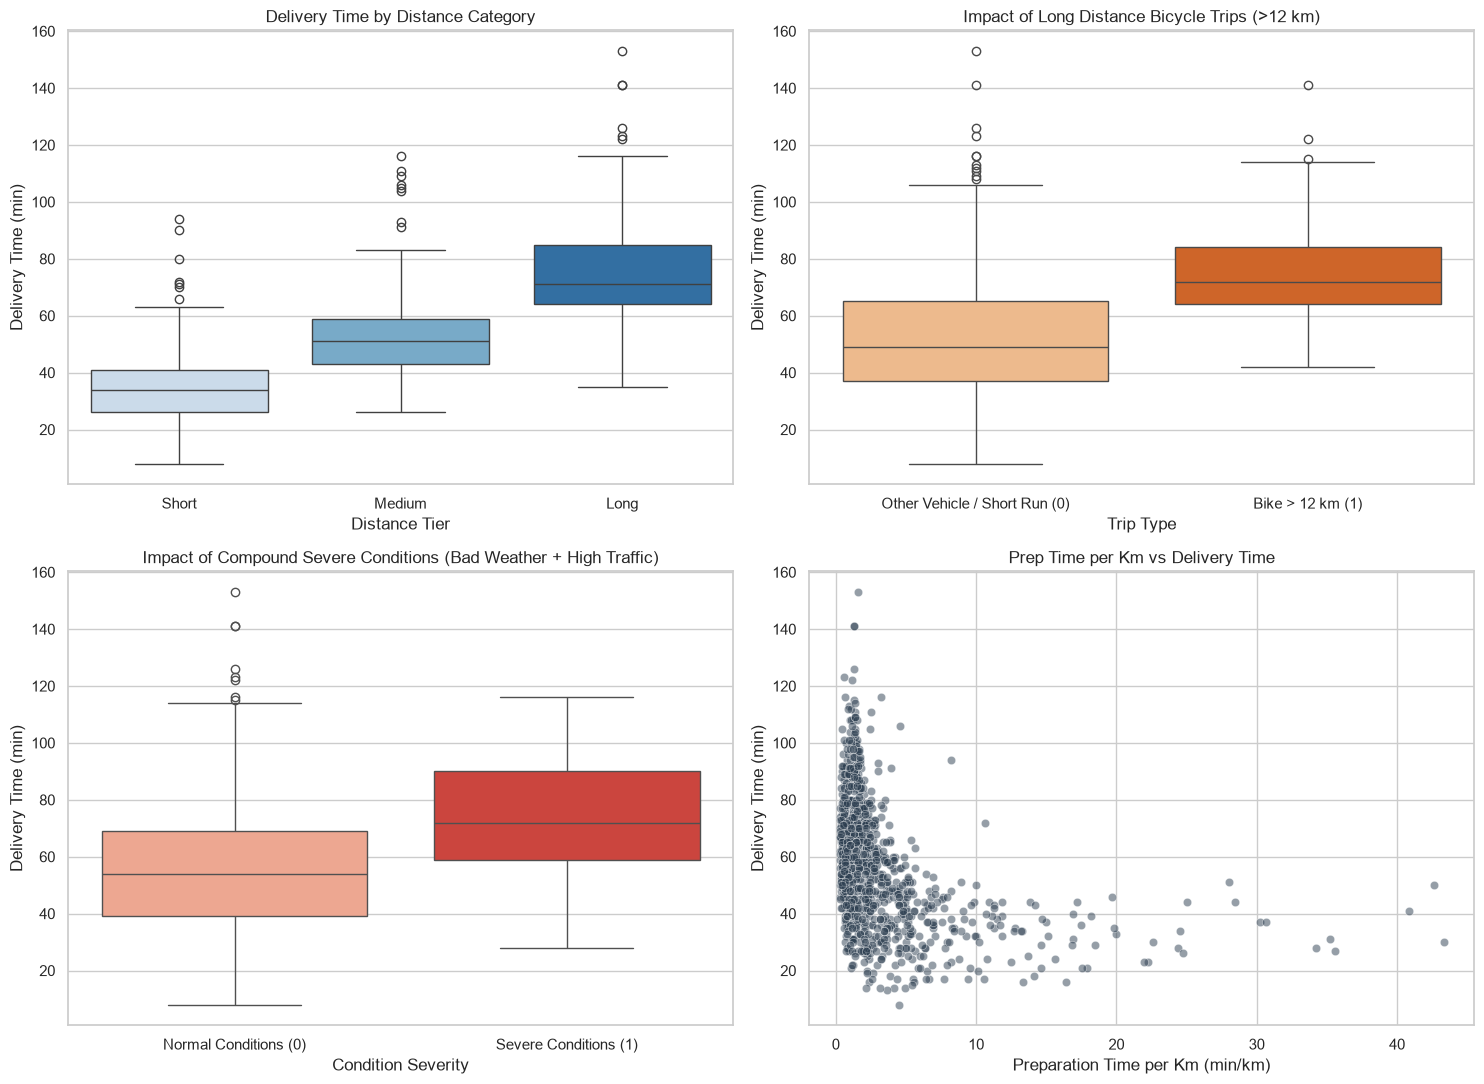

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: Distance Category vs Delivery Time
sns.boxplot(data=df_clean.assign(Distance_Category=X_fe['Distance_Category']), 
            x='Distance_Category', y='Delivery_Time_min', 
            order=['Short', 'Medium', 'Long'], ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Delivery Time by Distance Category')
axes[0, 0].set_xlabel('Distance Tier')
axes[0, 0].set_ylabel('Delivery Time (min)')

# Plot 2: Bike Long Distance vs Delivery Time
sns.boxplot(data=df_clean.assign(Bike_Long_Distance=X_fe['Bike_Long_Distance']), 
            x='Bike_Long_Distance', y='Delivery_Time_min', ax=axes[0, 1], palette='Oranges')
axes[0, 1].set_title('Impact of Long Distance Bicycle Trips (>12 km)')
axes[0, 1].set_xticklabels(['Other Vehicle / Short Run (0)', 'Bike > 12 km (1)'])
axes[0, 1].set_xlabel('Trip Type')
axes[0, 1].set_ylabel('Delivery Time (min)')

# Plot 3: Severe Conditions vs Delivery Time
sns.boxplot(data=df_clean.assign(Severe_Conditions=X_fe['Severe_Conditions']), 
            x='Severe_Conditions', y='Delivery_Time_min', ax=axes[1, 0], palette='Reds')
axes[1, 0].set_title('Impact of Compound Severe Conditions (Bad Weather + High Traffic)')
axes[1, 0].set_xticklabels(['Normal Conditions (0)', 'Severe Conditions (1)'])
axes[1, 0].set_xlabel('Condition Severity')
axes[1, 0].set_ylabel('Delivery Time (min)')

# Plot 4: Prep Time per Km vs Delivery Time
sns.scatterplot(data=df_clean.assign(Prep_Time_per_Km=X_fe['Prep_Time_per_Km']), 
                x='Prep_Time_per_Km', y='Delivery_Time_min', ax=axes[1, 1], 
                alpha=0.5, color='#2c3e50')
axes[1, 1].set_title('Prep Time per Km vs Delivery Time')
axes[1, 1].set_xlabel('Preparation Time per Km (min/km)')
axes[1, 1].set_ylabel('Delivery Time (min)')

plt.tight_layout()
plt.show()

In [9]:
# Quantify numerical differences for engineered binary/categorical features
print("=== Validation Summary of Engineered Features ===\n")

# 1. Distance Category breakdown
dist_stats = df_clean.assign(Distance_Category=X_fe['Distance_Category']).groupby('Distance_Category', observed=False)['Delivery_Time_min'].agg(
    Orders='count', Mean='mean', Median='median', Std='std'
).round(2)
print("--- 1. Distance_Category ---")
print(dist_stats)

# 2. Bike Long Distance breakdown
bike_stats = df_clean.assign(Bike_Long_Distance=X_fe['Bike_Long_Distance']).groupby('Bike_Long_Distance')['Delivery_Time_min'].agg(
    Orders='count', Mean='mean', Median='median', Std='std'
).round(2)
print("\n--- 2. Bike_Long_Distance (Vehicle x Distance) ---")
print(bike_stats)

# 3. Severe Conditions breakdown
cond_stats = df_clean.assign(Severe_Conditions=X_fe['Severe_Conditions']).groupby('Severe_Conditions')['Delivery_Time_min'].agg(
    Orders='count', Mean='mean', Median='median', Std='std'
).round(2)
print("\n--- 3. Severe_Conditions (Weather x Traffic) ---")
print(cond_stats)

# 4. Correlation of continuous engineered features with target
print("\n--- 4. Pearson Correlation with Delivery_Time_min ---")
corrs = {
    'Distance_km (Raw Baseline)': X_fe['Distance_km'].corr(y),
    'Bike_Long_Distance (Engineered)': X_fe['Bike_Long_Distance'].corr(y),
    'Prep_Time_per_Km (Engineered)': X_fe['Prep_Time_per_Km'].corr(y),
    'Severe_Conditions (Engineered)': X_fe['Severe_Conditions'].corr(y),
    'Is_Peak_Meal_Hour (Engineered)': X_fe['Is_Peak_Meal_Hour'].corr(y)
}
for name, val in corrs.items():
    print(f"  {name:35s}: {val:+.3f}")

=== Validation Summary of Engineered Features ===

--- 1. Distance_Category ---
                   Orders   Mean  Median    Std
Distance_Category                              
Long                  402  74.55    71.0  16.89
Medium                350  52.14    51.0  14.56
Short                 248  34.33    34.0  12.52

--- 2. Bike_Long_Distance (Vehicle x Distance) ---
                    Orders   Mean  Median    Std
Bike_Long_Distance                              
0                      797  52.19    49.0  21.10
1                      203  74.55    72.0  15.93

--- 3. Severe_Conditions (Weather x Traffic) ---
                   Orders   Mean  Median    Std
Severe_Conditions                              
0                     915  55.20    54.0  21.47
1                      85  73.18    72.0  21.84

--- 4. Pearson Correlation with Delivery_Time_min ---
  Distance_km (Raw Baseline)         : +0.781
  Bike_Long_Distance (Engineered)    : +0.408
  Prep_Time_per_Km (Engineered)      : -0.3

### Analysis & Empirical Validation
1. **`Distance_Category`**:
   * Short (< 5 km): Mean = **34.33 min**
   * Medium (5–12 km): Mean = **52.14 min**
   * Long (> 12 km): Mean = **74.55 min**
   * Confirms monotonic staircase progression across delivery radii.
2. **`Bike_Long_Distance` ($r = +0.408$)**:
   * Trips with `Bike_Long_Distance == 1` average **74.55 minutes** vs. **52.19 minutes** for other trips.
   * Demonstrates a huge **+22.36 minute delay penalty**, isolating an actionable physical interaction for non-linear and linear models alike.
3. **`Severe_Conditions` ($r = +0.227$)**:
   * Orders under severe conditions average **73.18 minutes** vs. **55.20 minutes** under normal conditions.
   * Confirms that compounding weather + traffic adds an average **+18.0 minute delay**.
4. **`Prep_Time_per_Km` ($r = -0.380$)**:
   * Strong inverse correlation reflecting the operational trade-off between kitchen-dominated short runs and transit-dominated long runs.

## 4. Reusable Scikit-Learn Custom Transformer

To ensure full reproducibility and eliminate any risk of code duplication between notebooks and production, we encapsulate this logic into a custom Scikit-Learn transformer: `DeliveryFeatureEngineer`.

In [7]:
class DeliveryFeatureEngineer(BaseEstimator, TransformerMixin):
    """Custom Scikit-Learn transformer for delivery domain feature engineering.
    
    Performs row-level deterministic transformations with zero data leakage.
    """
    
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        # Deterministic transformations require no fitting of statistical parameters
        return self
        
    def transform(self, X):
        X_out = X.copy()
        
        # 1. Distance Category (Short, Medium, Long)
        X_out['Distance_Category'] = pd.cut(
            X_out['Distance_km'], 
            bins=[0, 5, 12, np.inf], 
            labels=['Short', 'Medium', 'Long']
        ).astype(str)
        
        # 2. Peak Meal Hour Indicator (Evening dinner rush)
        X_out['Is_Peak_Meal_Hour'] = (X_out['Time_of_Day'] == 'Evening').astype(int)
        
        # 3. Preparation Time Intensity per Km
        X_out['Prep_Time_per_Km'] = (X_out['Preparation_Time_min'] / (X_out['Distance_km'] + 1e-5)).round(2)
        
        # 4. Vehicle x Distance Interaction (Bicycle > 12 km)
        X_out['Bike_Long_Distance'] = ((X_out['Vehicle_Type'] == 'Bike') & (X_out['Distance_km'] > 12.0)).astype(int)
        
        # 5. Compound Bottleneck Interaction (Hazardous Weather + High Traffic)
        adverse_weather = ['Snowy', 'Rainy', 'Foggy']
        X_out['Severe_Conditions'] = (
            X_out['Weather'].isin(adverse_weather) & 
            (X_out['Traffic_Level'] == 'High')
        ).astype(int)
        
        return X_out

# Test transformer
transformer = DeliveryFeatureEngineer()
X_transformed_test = transformer.transform(X)
print("Transformer successfully executed!")
print(f"Transformed output shape: {X_transformed_test.shape}")
print(f"Transformed columns: {list(X_transformed_test.columns)}")

Transformer successfully executed!
Transformed output shape: (1000, 12)
Transformed columns: ['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Distance_Category', 'Is_Peak_Meal_Hour', 'Prep_Time_per_Km', 'Bike_Long_Distance', 'Severe_Conditions']


## 5. Verification Against Data Leakage

### Rigorous Leakage Audit:
1. **Target Independence**: None of the engineered features utilize `Delivery_Time_min` directly or indirectly in their derivation. The target was isolated before any transformation.
2. **Global Statistic Independence**: No feature uses aggregate statistics (such as dataset-wide means, variances, medians, or quantiles). 
   * `Distance_Category` uses fixed physical cutoff constants ($5 \text{ km}, 12 \text{ km}$).
   * All ratios and compound booleans are strictly evaluated **row-by-row**.
3. **Train/Test Integrity**: When train/test splitting is conducted in Phase 6, applying `DeliveryFeatureEngineer` to the training set or test set yields mathematically identical, uncompromised feature values without information leakage.

## 6. Executive Summary & Readiness for Phase 6

### Summary of Feature Engineering Decisions:

| Category | Feature Name | Type | Formula / Logic | Physical Rationale |
| :--- | :--- | :--- | :--- | :--- |
| **Removed** | `Order_ID` | Identifier | `drop(Order_ID)` | Irrelevant transaction index with zero predictive value; prevents overfitting. |
| **Distance** | `Distance_Category` | Categorical | `cut([0, 5, 12, inf])` | Stratifies short (<5 km), mid (5–12 km), and long-haul (>12 km) delivery windows. |
| **Time** | `Is_Peak_Meal_Hour` | Binary Flag | `Time_of_Day == 'Evening'` | Captures restaurant kitchen backlogs and rush hour transit delay. |
| **Prep/Courier**| `Prep_Time_per_Km` | Continuous | `Prep_Time / Distance` | Distinguishes kitchen-dominated delays from transit-dominated delays. |
| **Interaction** | `Bike_Long_Distance` | Binary Flag | `Bike & Distance > 12` | Captures physical human speed ceiling and cyclist transit fatigue (+22.3 min penalty). |
| **Interaction** | `Severe_Conditions` | Binary Flag | `Adverse Weather & High Traffic` | Captures compound operational gridlock and road hazards (+18.0 min penalty). |

*Phase 5: Feature Engineering is completed. Ready for Phase 6: Train/Test Split.*